# K-Means Clustering on O*NET Career Data (Unscaled)

This notebook applies **K-Means clustering** to O*NET occupational data **without scaling** the features first. 

**Purpose of this notebook:**  
Compare clustering results with the scaled version.

**Key difference from scaled version:**  
Features with larger value ranges will dominate the distance calculations, potentially leading to less meaningful clusters.

## 1. Import Libraries

In [17]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning tools
from sklearn.decomposition import PCA             # For dimensionality reduction
from sklearn.cluster import KMeans                # Main clustering algorithm
from scipy.spatial.distance import cdist          # Distance calculations for elbow method

## 2. Initialize Tools

We create PCA objects.

In [18]:
# Initialize tools 
pca = PCA()

## 3. Load the Prepared Data

Load the career data prepared in the DataLoad&Prep notebook.

In [19]:
# Load the preprocessed career data
full_df = pd.read_csv('../Data/career_pivot_results.csv')
print('Full Data Frame')
print(full_df.head())

Full Data Frame
  O*NET-SOC Code                                Title  A: Arm-Hand Steadiness  \
0     11-1011.00                     Chief Executives                    0.50   
1     11-1011.03        Chief Sustainability Officers                    0.00   
2     11-1021.00      General and Operations Managers                    0.88   
3     11-2011.00  Advertising and Promotions Managers                    0.50   
4     11-2021.00                   Marketing Managers                    0.12   

   A: Auditory Attention  A: Category Flexibility  A: Control Precision  \
0                   2.00                     4.00                  0.75   
1                   1.75                     3.50                  0.50   
2                   2.00                     3.25                  0.12   
3                   1.25                     3.88                  0.12   
4                   1.62                     3.62                  0.00   

   A: Deductive Reasoning  A: Depth Perception

## 4. Extract Numeric Features

Extract only the numeric columns (skills/abilities) for clustering.

In [20]:
# Select only numeric columns (exclude job codes and titles)
numeric_df = full_df.select_dtypes(include=[np.number])
X = numeric_df.values  # Convert to numpy array

print(f"Shape: {X.shape}")  # (jobs, features)
print(f"Numeric columns: {numeric_df.columns.tolist()[:5]}...")

Shape: (894, 87)
Numeric columns: ['A: Arm-Hand Steadiness', 'A: Auditory Attention', 'A: Category Flexibility', 'A: Control Precision', 'A: Deductive Reasoning']...


## 5. Skip Scaling (Use Raw Data)

In [21]:

# Using the raw data set for comparison
# This keeps the original values (typically 0-7 scale for O*NET ratings)
X_unscaled = X

## 6. PCA Analysis

Apply PCA to understand which features drive the most variance. Note that PCA results will differ from the scaled version because PCA is also sensitive to feature scales.

Variance explained by PC1: 54.65%
Variance explained by PC2: 16.40%
Variance explained by PC3: 5.58%
Total variance with 2 components: 71.05%
Total variance with 3 components: 76.63%


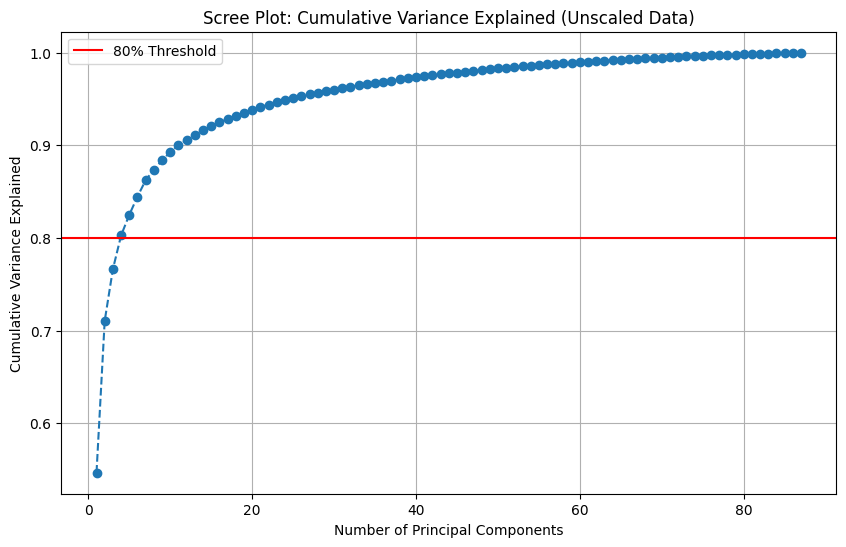

In [22]:
# Fit PCA to the data
pca.fit(X_unscaled)

# Get variance explained by each component
evr = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(evr)

# Unscaled PCA may show different patterns due to feature scale dominance
print(f"Variance explained by PC1: {evr[0]:.2%}")
print(f"Variance explained by PC2: {evr[1]:.2%}")
print(f"Variance explained by PC3: {evr[2]:.2%}")
print(f"Total variance with 2 components: {cumulative_variance[1]:.2%}")
print(f"Total variance with 3 components: {cumulative_variance[2]:.2%}")

# Scree Plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(evr) + 1), cumulative_variance, marker='o', linestyle='--')
plt.axhline(y=0.80, color='r', linestyle='-', label='80% Threshold')
plt.title('Scree Plot: Cumulative Variance Explained (Unscaled Data)')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Variance Explained')
plt.grid(True)
plt.legend()
plt.show()

### 6.1 Interpreting Principal Components

See which features contribute most to each principal component. With unscaled data, features with higher variance may dominate.

In [23]:
# Get feature names for interpretation
feature_names = numeric_df.columns

# Create loadings DataFrame showing feature contributions to each PC
loadings = pd.DataFrame(
    pca.components_, 
    columns=feature_names,
    index=[f'PC{i+1}' for i in range(len(pca.components_))]
)

def interpret_component(pc_name):
    """Display top positive and negative contributors to a principal component"""
    print(f"*** {pc_name} Interpretation ***")
    
    # Top positive contributors
    top_pos = loadings.loc[pc_name].nlargest(5)
    print("Top Positive (High Values):")
    print(top_pos)
    print("-" * 20)
    
    # Top negative contributors
    top_neg = loadings.loc[pc_name].nsmallest(5)
    print("Top Negative (Low Values):")
    print(top_neg)
    print("\n")

# Interpret first 3 components
interpret_component('PC1')
interpret_component('PC2')
interpret_component('PC3')

*** PC1 Interpretation ***
Top Positive (High Values):
A: Multilimb Coordination    0.219762
A: Extent Flexibility        0.219546
A: Static Strength           0.215546
A: Reaction Time             0.212664
A: Control Precision         0.201450
Name: PC1, dtype: float64
--------------------
Top Negative (Low Values):
A: Written Expression      -0.138657
A: Written Comprehension   -0.118290
S: Writing                 -0.111496
S: Reading Comprehension   -0.102654
A: Oral Expression         -0.100255
Name: PC1, dtype: float64


*** PC2 Interpretation ***
Top Positive (High Values):
S: Science                     0.261365
A: Mathematical Reasoning      0.186522
S: Quality Control Analysis    0.167087
S: Operations Monitoring       0.160421
A: Visualization               0.159145
Name: PC2, dtype: float64
--------------------
Top Negative (Low Values):
A: Dynamic Flexibility       -0.011742
A: Trunk Strength            -0.008356
A: Stamina                   -0.006219
A: Dynamic Strength   

### 6.2 Feature Loadings Heatmap

Visualize which skills define each principal component.

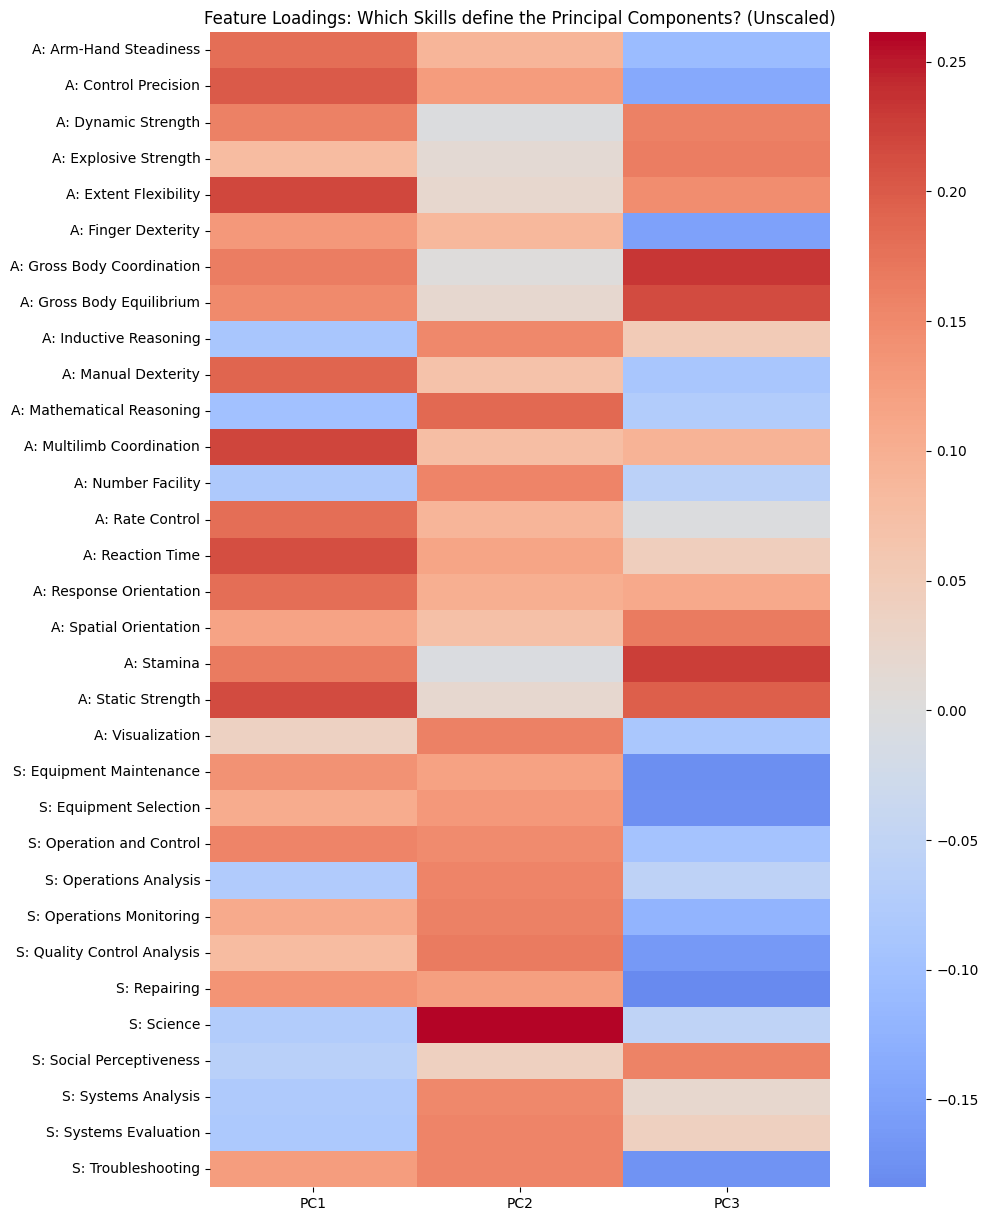

In [24]:
# Heatmap of feature loadings for top 3 principal components
plt.figure(figsize=(10, 15))

# Transpose so skills are rows, PCs are columns
subset = loadings.iloc[:3].T 

# Filter to show only features with strong loadings (|loading| > 0.15)
filtered_subset = subset[(subset.abs() > 0.15).any(axis=1)]

sns.heatmap(filtered_subset, cmap='coolwarm', center=0, annot=False)
plt.title("Feature Loadings: Which Skills define the Principal Components? (Unscaled)")
plt.show()

## 7. Visualizing the Data in 2D Space

Reduce to 2 dimensions using PCA for visualization. Each point is one occupation.

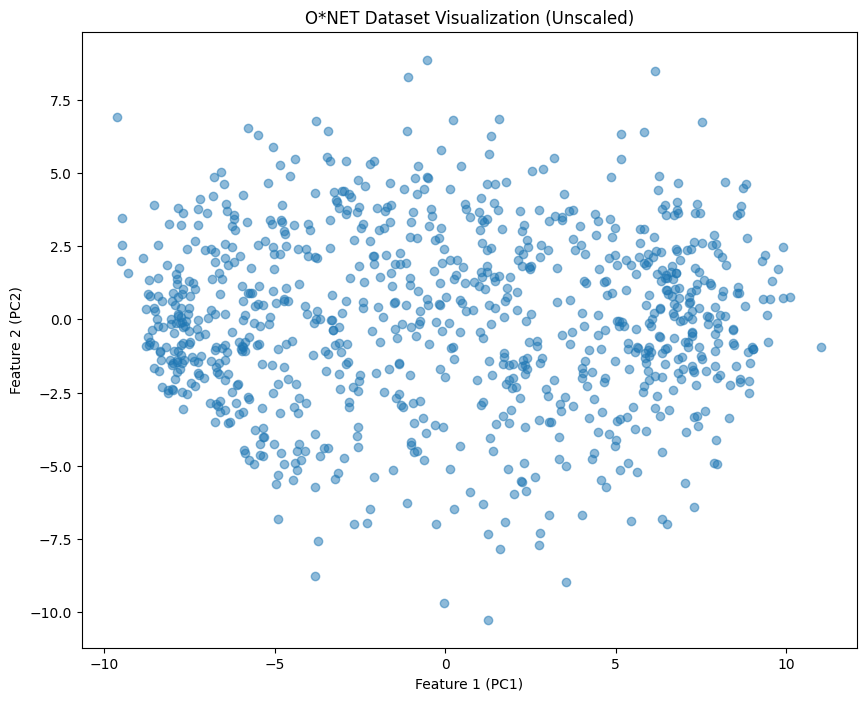

In [25]:
# Reduce to 2D for plotting
pca_simple = PCA(n_components=2)
coords = pca_simple.fit_transform(X_unscaled)

x1 = coords[:, 0]
x2 = coords[:, 1]

# Scatter plot of all occupations
plt.figure(figsize=(10, 8))
plt.scatter(x1, x2, marker='o', alpha=0.5)

plt.title('O*NET Dataset Visualization (Unscaled)')
plt.xlabel('Feature 1 (PC1)')
plt.ylabel('Feature 2 (PC2)')
plt.show()

## 8. Elbow Method - Finding Optimal k

Test different numbers of clusters to find the "elbow" where adding more clusters stops improving results significantly.

In [26]:
# Test k from 1 to 19 clusters
distortions = []  # Average squared distance to cluster center
inertias = []     # Sum of squared distances
mapping1 = {}
mapping2 = {}
K = range(1, 20)

for k in K:
    # Fit K-Means for each k value
    kmeanModel = KMeans(n_clusters=k, n_init=20, random_state=42).fit(X_unscaled)
    
    # Calculate distortion
    distortions.append(sum(np.min(cdist(X_unscaled, kmeanModel.cluster_centers_, 'euclidean'), axis=1)**2) / X_unscaled.shape[0])
    inertias.append(kmeanModel.inertia_)
    
    mapping1[k] = distortions[-1]
    mapping2[k] = inertias[-1]

### 8.1 Elbow Plot - Distortion

Distortion values:
1 : 54.42463995518841
2 : 31.489633846735458
3 : 26.895968182281027
4 : 23.40157793867668
5 : 21.619008428819544
6 : 20.199671125815218
7 : 19.27013216426726
8 : 18.5007358332441
9 : 17.911292177729155
10 : 17.436127485824258
11 : 16.900925942846982
12 : 16.48159398638451
13 : 16.104986303974844
14 : 15.746432825745137
15 : 15.389610126566847
16 : 15.07023875226718
17 : 14.939179446819457
18 : 14.580730761026478
19 : 14.354913525234684


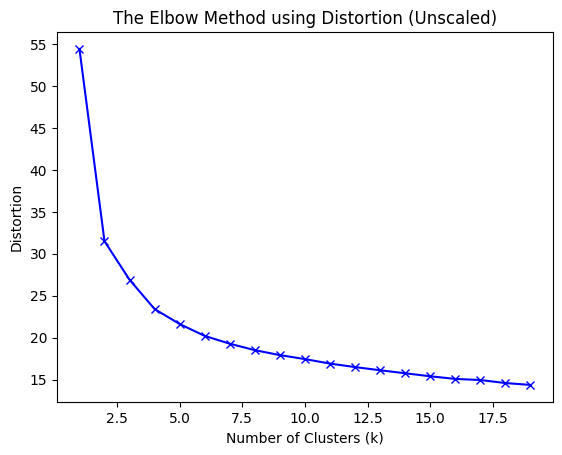

In [27]:
# Print distortion values
print("Distortion values:")
for key, val in mapping1.items():
    print(f'{key} : {val}')

# Plot elbow curve
plt.plot(K, distortions, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Distortion')
plt.title('The Elbow Method using Distortion (Unscaled)')
plt.show()

### 8.2 Elbow Plot - Inertia

Inertia values:
1 : 48655.62811993848
2 : 28151.732658981535
3 : 24044.99555495925
4 : 20921.010677176953
5 : 19327.393535364652
6 : 18058.50598647879
7 : 17227.498154854926
8 : 16539.657834920246
9 : 16012.695206889835
10 : 15587.897972326902
11 : 15109.427792905213
12 : 14734.545023827743
13 : 14397.857755753515
14 : 14077.310946216161
15 : 13758.31145315077
16 : 13472.793444526847
17 : 13355.626425456601
18 : 13035.173300357683
19 : 12833.292691559802


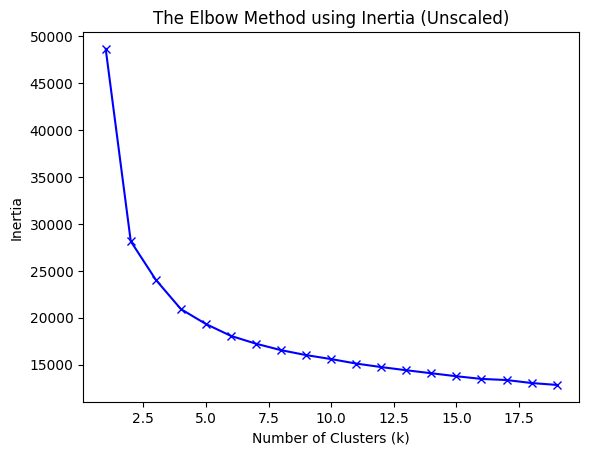

In [28]:
# Print inertia values
print("Inertia values:")
for key, val in mapping2.items():
    print(f'{key} : {val}')

# Plot elbow curve
plt.plot(K, inertias, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('The Elbow Method using Inertia (Unscaled)')
plt.show()

## 9. Run K-Means Clustering

Apply K-Means clustering using sklearn's optimized implementation with k=7 clusters (based on elbow method).

In [29]:
# Run K-Means on the unscaled data
# K=7 clusters (based on elbow method)
kmeans_unscaled = KMeans(n_clusters=7, random_state=42, n_init=20)
labels = kmeans_unscaled.fit_predict(X_unscaled)

# Save cluster labels back to the dataframe
full_df['Unscaled_KMeans_Cluster'] = labels

print(f"Cluster distribution:\n{pd.Series(labels).value_counts().sort_index()}")

Cluster distribution:
0    149
1    106
2    124
3     97
4    100
5    158
6    160
Name: count, dtype: int64


### 9.1 Visualize K-Means Clustering Results

Points colored by cluster assignment. Triangles show the centroid positions.

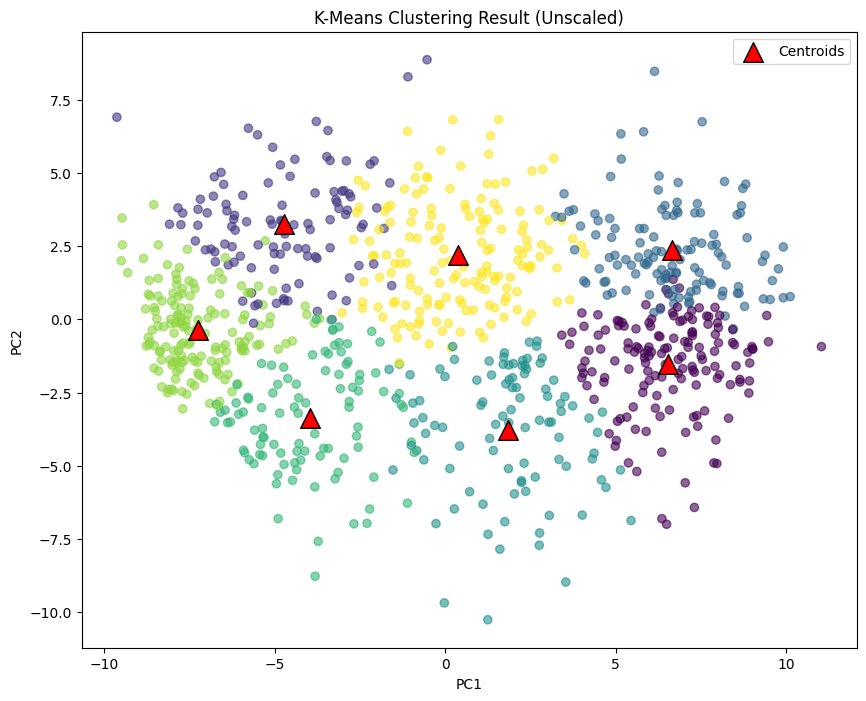

In [30]:
# Plot results: points colored by cluster, centroids as red triangles
plt.figure(figsize=(10, 8))
plt.scatter(x1, x2, c=labels, cmap='viridis', alpha=0.6)

# Plot centroids (projected to 2D using PCA)
pca_2d = PCA(n_components=2)
pca_2d.fit(X_unscaled)
centroids_2d = pca_2d.transform(kmeans_unscaled.cluster_centers_)
plt.scatter(centroids_2d[:, 0], centroids_2d[:, 1], marker='^', c='red', s=200, edgecolors='black', label='Centroids')

plt.title('K-Means Clustering Result (Unscaled)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()

### 9.2 Explore Cluster Contents

View the top 5 largest clusters and sample 8 jobs from each to understand what types of occupations are grouped together.

In [31]:
# Get cluster sizes and identify top 5 largest clusters
cluster_sizes = full_df['Unscaled_KMeans_Cluster'].value_counts().sort_values(ascending=False)
top_5_clusters = cluster_sizes.head(5).index.tolist()

print("Top 5 Largest Clusters:")
print(cluster_sizes.head(5))
print("\n" + "="*60 + "\n")

# Show top 8 jobs from each of the top 5 clusters
for cluster_id in top_5_clusters:
    cluster_jobs = full_df[full_df['Unscaled_KMeans_Cluster'] == cluster_id]['Title']
    
    print(f"CLUSTER {cluster_id} ({len(cluster_jobs)} jobs)")
    print("-" * 40)
    
    # Show first 8 jobs in this cluster
    for i, job in enumerate(cluster_jobs.head(8), 1):
        print(f"  {i}. {job}")
    
    print("\n")

Top 5 Largest Clusters:
Unscaled_KMeans_Cluster
6    160
5    158
0    149
2    124
1    106
Name: count, dtype: int64


CLUSTER 6 (160 jobs)
----------------------------------------
  1. Facilities Managers
  2. Security Managers
  3. Industrial Production Managers
  4. Geothermal Production Managers
  5. Biofuels Production Managers
  6. Biomass Power Plant Managers
  7. Hydroelectric Production Managers
  8. Farmers, Ranchers, and Other Agricultural Managers


CLUSTER 5 (158 jobs)
----------------------------------------
  1. Chief Executives
  2. Chief Sustainability Officers
  3. General and Operations Managers
  4. Advertising and Promotions Managers
  5. Marketing Managers
  6. Sales Managers
  7. Fundraising Managers
  8. Financial Managers


CLUSTER 0 (149 jobs)
----------------------------------------
  1. Athletes and Sports Competitors
  2. Medical Equipment Preparers
  3. Endoscopy Technicians
  4. Parking Enforcement Workers
  5. Transportation Security Screeners
  6. Dis

## 10. Evaluate Clustering Quality: Silhouette Score

The **Silhouette Score** measures how well-defined the clusters are:
- Ranges from -1 to +1
- **+1**: Points are well-matched to their own cluster and poorly-matched to others (good!)
- **0**: Points are on cluster boundaries
- **-1**: Points may be assigned to the wrong cluster

A score above 0.5 is generally considered good clustering.

In [32]:
from sklearn.metrics import silhouette_score

# Calculate silhouette score on the unscaled data
score = silhouette_score(X_unscaled, kmeans_unscaled.labels_)

print(f"Silhouette Score: {score:.3f}")
# Interpretation: closer to 1 = better defined clusters

Silhouette Score: 0.153


---

## 📋 Summary: K-Means Clustering (Unscaled Data)

### Purpose of This Notebook
This notebook intentionally **skips standardization** to understand why preprocessing matters for K-Means clustering.

### Next Step:
Look at Hierarchical Clustering in file 05